In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import glob
import numpy as np
from itertools import chain
from scipy.stats import rankdata

In [2]:
cl100k = pd.read_pickle("/path/to/project/records/comp/fineweb2_hq/o200k_ratio/results.pkl")
domain_cols = cl100k.columns.drop("tok_name")
cl100k["concat"] = cl100k[domain_cols].apply(lambda row: list(chain.from_iterable(row)), axis=1)
cl100k = cl100k[["tok_name","concat"]]

In [3]:
records = sorted(
    glob.glob("/path/to/project/records/comp/fineweb2_trex_valid/fineweb2_hq_valid/*/*.pkl"),
    key=lambda x: (
        float(x.split("/")[-2].split("_")[0].replace("gb", "")),
        float(x.split("/")[-2].split("_")[1].replace("k", ""))
    )
)

In [4]:
dfs = {"_".join(record.split("/")[-2].split("_")[:2]): pd.read_pickle(record) for record in records}

In [5]:
for i in dfs.keys():
    print(i)
    dfs[i]["concat"] = dfs[i][domain_cols].apply(lambda row: list(chain.from_iterable(row)), axis=1)
    dfs[i] = dfs[i][["tok_name","concat"]].reset_index(drop=True)

1gb_64k
5gb_64k
10gb_100k
30gb_200k


In [6]:
available_keys = [
    '1gb_64k',
    '5gb_64k',
    '10gb_100k',
    '30gb_200k'
]

#### ALL Domain

### Average Domain

In [7]:
domains = dfs['1gb_64k'].columns[1:]
def prepare_arr_y_from_df(df_y, cl100k):
    dist = []
    for idx in range(len(df_y)):  
        dist_per_tokenizer = []
        for domain in domains:    
            num = sum(df_y.loc[idx, domain])  
            den = sum(cl100k.loc[0, domain])  
            ratio = num / den if den != 0 else np.nan
            dist_per_tokenizer.append(ratio)
        dist.append(dist_per_tokenizer)
    return np.array(dist)

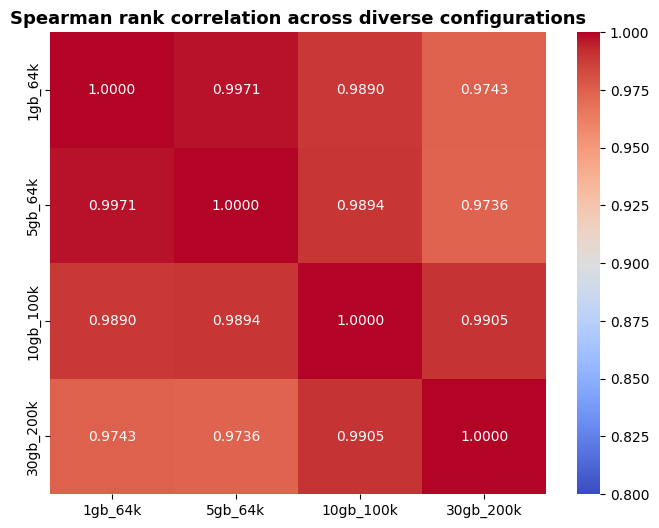

In [10]:
# 평균 점수 기반 순위 비교
mean_data = {}
for name, df in dfs.items():
    arr = prepare_arr_y_from_df(df, cl100k)
    df["mean_score"] = arr.mean(1)
    mean_data[name] = df["mean_score"].values
# 상관계수 매트릭스
mean_corr = pd.DataFrame(index=mean_data.keys(), columns=mean_data.keys(), dtype=float)
for g1 in mean_data:
    for g2 in mean_data:
        rho, _ = spearmanr(mean_data[g1], mean_data[g2])
        mean_corr.loc[g1, g2] = rho

# 히트맵 플롯
plt.figure(figsize=(8, 6))
sns.heatmap(mean_corr.astype(float), cmap="coolwarm", vmin=0.8, vmax=1.0, annot=True, fmt=".4f")
plt.title("Spearman rank correlation across diverse configurations", fontsize=13, fontweight='bold')
plt.show()